# Final Evaluation

This notebook analyzes the final performance of the six classification models
on the untouched 2024–2025 test period.

All model development, hyperparameter selection and feature analysis were
completed before accessing the final test set. The final models were trained
using all available pre-test data from 2015–2023.

No models are trained again in this notebook. It uses only the final metrics and predictions saved during final model training.

The analysis includes:
- the overall performance of the six models
- the models with the ranking baseline and bookmaker predictions
- performance in different years and surfaces
- easier and more difficult matches
- ranking upsets
- model agreement
- prediction confidence and high-confidence mistakes

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    log_loss
)

In [2]:
# folder containing the final model results and predictions
FINAL_RESULTS_DIR = Path(
    "../results/final"
)

## Load the final results 

The models were already trained and evaluated in the previous notebook.

Here we load:
- one table containing the final metrics of the six models
- one table used to compare them with the ranking baseline
- the prediction made by every model for every test match

In [3]:
# final metrics for the six machine-learning models
final_model_results = pd.read_csv(
    FINAL_RESULTS_DIR
    / "final_model_results.csv"
)

# results including the ranking baseline
final_test_comparison = pd.read_csv(
    FINAL_RESULTS_DIR
    / "final_test_comparison.csv"
)

# individual predictions for each test match 
final_test_predictions = pd.read_csv(
    FINAL_RESULTS_DIR
    / "final_test_predictions.csv",
    parse_dates=["Date"]
)   

print(
    "Model results:",
    final_model_results.shape
)

print(
    "Comparison:",
    final_test_comparison.shape
)

print(
    "Test predictions:",
    final_test_predictions.shape
)

Model results: (6, 8)
Comparison: (7, 8)
Test predictions: (5119, 42)


In [4]:
# there should be exactly 6 models
assert len(final_model_results) == 6

# six models + better-ranked player baseline
assert len(final_test_comparison) == 7

# expected number of matches in the untouched test set
assert len( final_test_predictions) == 5119

# the test set should contain only 2024 and 2025 matches
assert set(
    final_test_predictions["Date"].dt.year.unique()
) == {
    2024,
    2025
}


print("Final evaluation files are correct.")

Final evaluation files are correct.


## Overall model performance

We first compare the six final models using the main metrics used throughout the project.

Accuracy gives the proportion of matches predicted correctly, while balanced accuracy checks performance across both classes.

ROC-AUC evaluates how well the model separates winners from losers using its predicted probabilities, independently of one fixed classification threshold.

LogLoss evaluates the probabilities themselves, so lower values are better.

In [5]:
display(final_model_results.round(4))

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss
0,XGBoost,0.6509,0.6510,0.6597,0.6386,0.6490,0.7119,0.6179
1,AdaBoost,0.6480,0.6480,0.6537,0.6451,0.6494,0.7104,0.6249
2,LightGBM,0.6476,0.6478,0.6591,0.6270,0.6426,0.7092,0.6205
3,Random Forest,0.6466,0.6468,0.6583,0.6254,0.6414,0.7098,0.6190
4,k-NN,0.6423,0.6427,0.6586,0.6069,0.6317,0.6991,0.6289
5,ANN,0.6396,0.6397,0.6479,0.6281,0.6379,0.7041,0.6236


XGBoost gives the best overall result, with approximately **65.1% accuracy** and a **ROC-AUC of 0.712**.

However, AdaBoost, LightGBM and Random Forest are very close. This suggests that the tree-based ensemble models perform similarly well on this problem rather than one model being much better than all the others.

k-NN and ANN obtain slightly lower final accuracy.

### Compare final accuracy

The following graph makes the difference in accuracy between the models and the ranking baseline easy to see. 

Since the models have similar accuracies, we decided to restrict the x-axis around the observed values instead of starting from 0. 

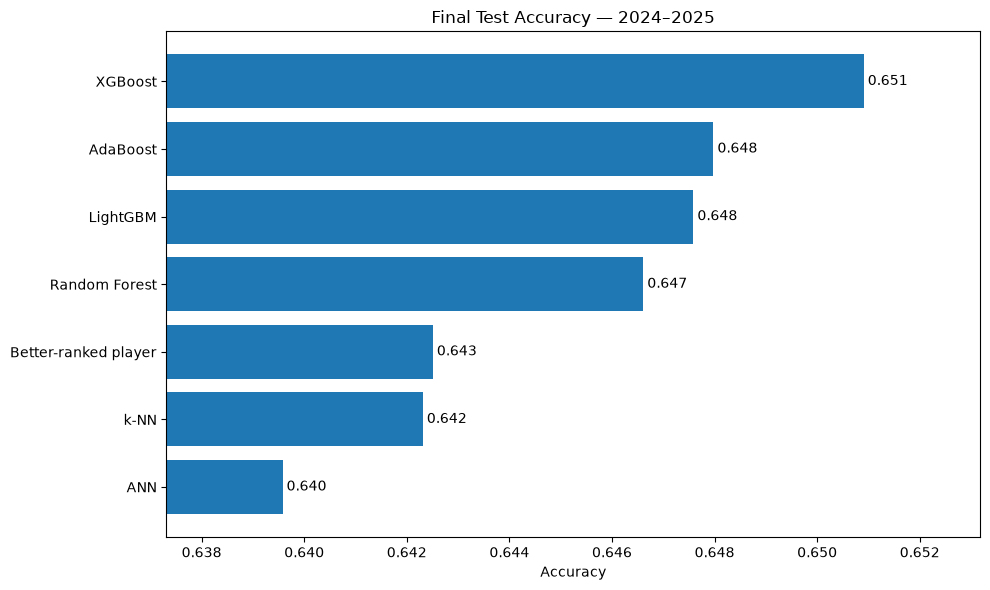

In [6]:
# order the methods from lowest to highest accuracy
plot_data = (
    final_test_comparison
    .sort_values(
        "Accuracy",
        ascending=True
    )
)

# use the observed accuracy range to create a more readable graph
min_accuracy = plot_data["Accuracy"].min()
max_accuracy = plot_data["Accuracy"].max()

difference = max_accuracy - min_accuracy

padding = max(
    difference * 0.20,
    0.001
)

plt.figure(
    figsize=(10, 6)
)


bars = plt.barh(
    plot_data["Model"],
    plot_data["Accuracy"]
)

plt.xlim(
    min_accuracy - padding,
    max_accuracy + padding
)


plt.xlabel("Accuracy")

plt.title("Final Test Accuracy — 2024–2025")

# write the accuracy next to every bar
for bar, value in zip(
    bars,
    plot_data["Accuracy"]
):

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.3f}",
        va="center"
    )

plt.tight_layout()

plt.show()

### Improvement over the baseline 

The better-ranked-player baseline is especially important because ATP ranking already gives a strong indication of which player is expected to win.

For each machine-learning model we calculate how much its accuracy improves, or decreases, compared with this simple rule. 

In [7]:
# accuracy obtained by always predicting the better-ranked player
baseline_accuracy = (
    final_test_comparison.loc[
        final_test_comparison["Model"] == "Better-ranked player",
        "Accuracy"
    ].iloc[0]
)

accuracy_gain = (
    final_model_results[
        [
            "Model",
            "Accuracy"
        ]
    ].copy()
)

# raw difference in accuracy
accuracy_gain["GainVsBaseline"] = (
    accuracy_gain["Accuracy"]
    - baseline_accuracy
)

# express the difference in percentage points to make it easier to read
accuracy_gain["GainPercentagePoints"] = (
    accuracy_gain["GainVsBaseline"] * 100
)

accuracy_gain.sort_values(
    "GainVsBaseline",
    ascending=False
)

,Model,Accuracy,GainVsBaseline,GainPercentagePoints
0,XGBoost,0.650908,0.008400,0.840008
1,AdaBoost,0.647978,0.005470,0.546982
2,LightGBM,0.647587,0.005079,0.507912
3,Random Forest,0.646611,0.004102,0.410236
4,k-NN,0.642313,-0.000195,-0.019535
5,ANN,0.639578,-0.002930,-0.293026


XGBoost improves on the ranking baseline by approximately **0.84 percentage points**.

The improvement is therefore real but quite small. This shows that ATP ranking by itself is already a difficult baseline to beat.

k-NN performs approximately at baseline level, while ANN performs slightly below it.

## External Bookmaker Benchmark

Betting odds were intentionally not included as model features.

The purpose of the project is to see how much we can predict using tennis-related information such as ranking, form, surface performance and previous results.

Bookmaker odds already combine many different sources of information and represent the market's expectation about a match. If we included them as features, the model could partly learn to reproduce bookmaker predictions instead of learning only from the tennis features created in this project.

For this reason, betting odds are used here only as an external benchmark after all model development is finished.. They were not used for feature engineering, hyperparameter tuning, model selection, or training of the final models.

In [8]:
PROCESSED_DATA_DIR = Path("../data/processed")

# load only the columns needed for the bookmaker comparison
odds_data = pd.read_csv(
    PROCESSED_DATA_DIR
    / "feature_split_matches.csv",
    usecols=[
        "MatchID",
        "DataSplit",
        "Player1AvgOdds",
        "Player2AvgOdds"
    ]
)

In [9]:
# keep only bookmaker odds for matches in the final test set
test_odds= (odds_data.loc[
    odds_data["DataSplit"]
    ==
    "Test",
    [
        "MatchID",
        "Player1AvgOdds",
        "Player2AvgOdds"
    ]
].copy())

# every MatchID should appear only once
assert(test_odds["MatchID"].is_unique)

print(
    "Test matches with odds data",
    len(test_odds)
)

Test matches with odds data 5119


In [10]:
# add the bookmaker odds to the saved final predictions
bookmaker_analysis= (final_test_predictions.merge(
    test_odds,
    on="MatchID",
    how="left",
    
    # Each MatchID should correspond to at most one row in each table.
    validate="one_to_one" 
))

# identify matches where both players have bookmaker odds 
odds_available= (
    bookmaker_analysis[
        [
            "Player1AvgOdds",
            "Player2AvgOdds"
        ]
    ].notna().all(axis=1)
)

# odds should also be greater than 1 to be valid decimal odds
odds_available=(
    odds_available
    &
    (bookmaker_analysis["Player1AvgOdds"] > 1)
    &
    (bookmaker_analysis["Player2AvgOdds"] > 1)
)

In [11]:
# keep only matches for which valid odds are available
bookmaker_subset = (
    bookmaker_analysis.loc[
        odds_available
    ].copy()
)

print(
    "Matches with valid bookmaker odds:",
    len(bookmaker_subset)
)

print(
    "Coverage:", 
    round(
        len(bookmaker_subset) / len(bookmaker_analysis) * 100,
        2
    ),
    "%"
)

Matches with valid bookmaker odds: 5114
Coverage: 99.9 %


### Convert bookmaker odds into predictions

With decimal betting odds, the player with the lower odds is considered the favorite.
We therefore predict Player 1 when Player 1 has lower average odds than Player 2.

In [12]:
# lower odds mean the bookmaker considers that player more likely to win
bookmaker_subset[
    "BookmakerPrediction"
] = (
    bookmaker_subset["Player1AvgOdds"]
    <
    bookmaker_subset["Player2AvgOdds"]
).astype(int)

# check whether the bookmaker favorite actually won
bookmaker_subset[
    "BookmakerCorrect"
] = (
    bookmaker_subset["BookmakerPrediction"]
    ==
    bookmaker_subset["Player1Won"]
)

In [13]:
# decimal odds can be converted to approximate implied probabilities
# If decimal odds are 2.00 -> 1 / 2 = 0.5 = 50% implied probability.
player1_implied = (1 / bookmaker_subset["Player1AvgOdds"])
player2_implied = (1 / bookmaker_subset["Player2AvgOdds"])

In [14]:
# bookmaker probabilities normally include a margin,
# so the two implied probabilities usually sum to more than 1
# normalize them so that Player 1 and Player 2 probabilities sum to 1
bookmaker_subset[
    "BookmakerProbability"
] = (
    player1_implied / (player1_implied + player2_implied)
)

# this gives an approximate market probability that Player 1 wins

In [15]:
# evaluate the bookmaker predictions using the same type of metrics
bookmaker_accuracy = (
    bookmaker_subset["BookmakerCorrect"].mean()
)

bookmaker_auc = roc_auc_score(
    bookmaker_subset["Player1Won"],
    bookmaker_subset["BookmakerProbability"]
)

bookmaker_log_loss = log_loss(
    bookmaker_subset["Player1Won"],
    bookmaker_subset["BookmakerProbability"]
)

print(
    "Bookmaker accuracy:",
    round(bookmaker_accuracy, 4)
)

print(
    "Bookmaker ROC-AUC:",
    round(bookmaker_auc, 4)
)

print(
    "Bookmaker log loss:",
    round(bookmaker_log_loss, 4)
)

Bookmaker accuracy: 0.685
Bookmaker ROC-AUC: 0.7529
Bookmaker log loss: 0.5864


In [16]:
# five test matches do not have valid bookmaker odds
# so the bookmaker is evaluated on 5,114 matches instead of all 5,119

# for a fair comparison, recalculate XGBoost and the ranking baseline
# using exactly the same 5,114 matches

xgboost_subset_accuracy = (
    bookmaker_subset["XGBoostCorrect"].mean()
)

xgboost_subset_auc = (
    roc_auc_score(
        bookmaker_subset["Player1Won"],
        bookmaker_subset["XGBoostProbability"]
    )
)

xgboost_subset_log_loss = (
    log_loss(
        bookmaker_subset["Player1Won"],
        bookmaker_subset["XGBoostProbability"]
    )
)

ranking_subset_accuracy = (
    bookmaker_subset["RankingBaselineCorrect"].mean()
)

In [17]:
# compare the three methods on exactly the same matches
bookmaker_comparison = pd.DataFrame(
    [
        {
            "Method":"XGBoost",
            "Matches": len(bookmaker_subset),
            "Accuracy": xgboost_subset_accuracy,
            "ROC-AUC": xgboost_subset_auc,
            "LogLoss": xgboost_subset_log_loss
        },
        
        {
            "Method":"Bookmaker Market",
            "Matches": len(bookmaker_subset),
            "Accuracy": bookmaker_accuracy,
            "ROC-AUC": bookmaker_auc,
            "LogLoss": bookmaker_log_loss
        },
        
        {
            "Method":"Better-ranked player",
            "Matches": len(bookmaker_subset),
            "Accuracy": ranking_subset_accuracy,
            "ROC-AUC": np.nan,
            "LogLoss": np.nan
        }
    ]
)

display( bookmaker_comparison.round(4))

,Method,Matches,Accuracy,ROC-AUC,LogLoss
0,XGBoost,5114,0.6506,0.7115,0.6181
1,Bookmaker Market,5114,0.6850,0.7529,0.5864
2,Better-ranked player,5114,0.6422,NaN,NaN


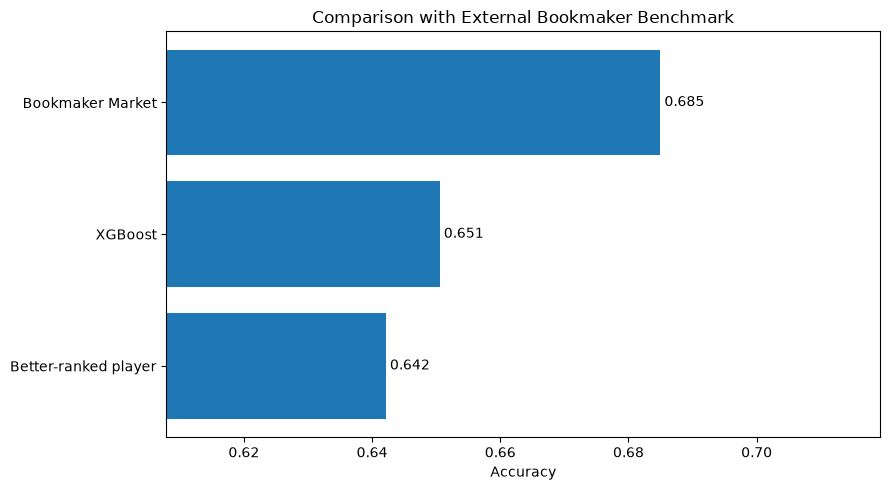

In [18]:
# plot bookmaker, XGBoost and ranking-baseline accuracy
bookmaker_plot_data = (
    bookmaker_comparison
    .sort_values(
        "Accuracy",
        ascending=True
    )
)

min_accuracy = bookmaker_plot_data["Accuracy"].min()
max_accuracy = bookmaker_plot_data["Accuracy"].max()

difference = max_accuracy - min_accuracy

padding = max(
    difference * 0.80,
    0.001
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    bookmaker_plot_data["Method"],
    bookmaker_plot_data["Accuracy"]
)

plt.xlim(
    min_accuracy - padding,
    max_accuracy + padding
)

plt.xlabel("Accuracy")

plt.title("Comparison with External Bookmaker Benchmark")

for bar, value in zip (
    bars,
    bookmaker_plot_data["Accuracy"]
):
    plt.text(
        value,
        bar.get_y()
        + bar.get_height() / 2,
        f" {value:.3f}",
        va = "center"
    )

plt.tight_layout()

plt.show()

In [19]:
# save the bookmaker comparison for the final report
bookmaker_comparison.to_csv(
    FINAL_RESULTS_DIR
    / "bookmaker_benchmark.csv",
    index=False
)

print("Bookmaker benchmark saved.")

Bookmaker benchmark saved.


The bookmaker performs better than both XGBoost and the simple ranking baseline.

On the same 5,114 matches, bookmaker predictions reach approximately **68.5% accuracy**, compared with **65.1% for XGBoost** and **64.2% for the better-ranked-player baseline**.

The bookmaker also obtains a higher ROC-AUC and lower LogLoss than XGBoost.

This suggests that the betting market contains useful information that is not completely represented by the historical features available in our dataset.

### ROC-AUC comparison

Accuracy looks only at the final predicted class.

ROC-AUC instead evaluates how well each model ranks positive and negative examples using the predicted probabilities.

We therefore also compare the six models using ROC-AUC.

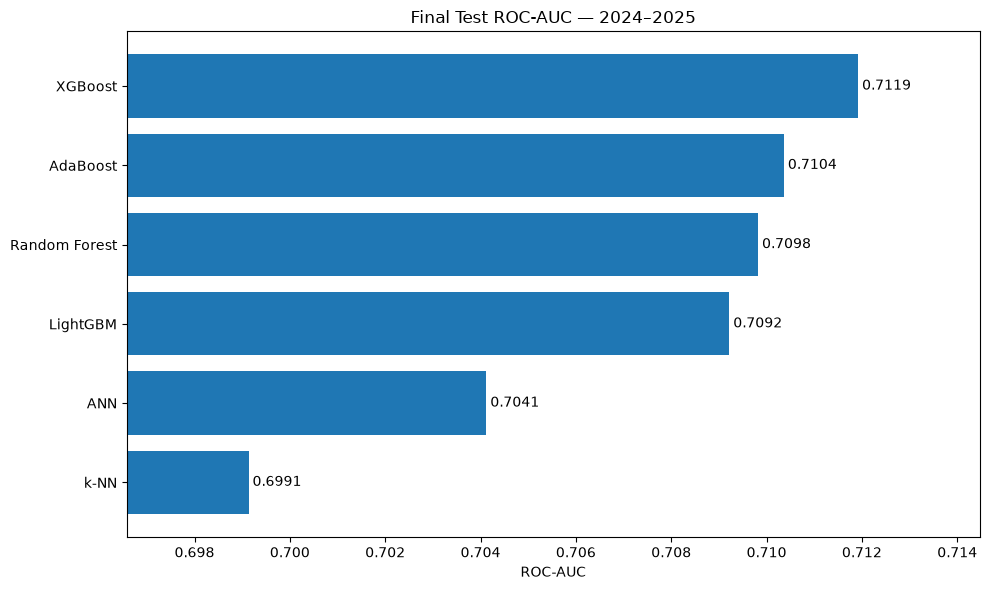

In [20]:
# order models by ROC-AUC for the plot
plot_data = (
    final_model_results
    .sort_values(
        "ROC-AUC",
        ascending=True
    )
)

min_rocauc = plot_data["ROC-AUC"].min()
max_rocauc = plot_data["ROC-AUC"].max()

difference = max_rocauc - min_rocauc

padding = max(
    difference * 0.20,
    0.001
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_data["Model"],
    plot_data["ROC-AUC"]
)

plt.xlim(
    min_rocauc - padding,
    max_rocauc + padding
)


plt.xlabel("ROC-AUC")

plt.title("Final Test ROC-AUC — 2024–2025")

for bar, value in zip (
    bars,
    plot_data["ROC-AUC"]
):
    plt.text(
        value,
        bar.get_y()
        + bar.get_height() / 2,
        f" {value:.4f}",
        va = "center"
    )

plt.tight_layout()

plt.show()

The ROC-AUC results are also very close between the main ensemble models.

XGBoost achieves the highest value at approximately **0.712**, followed closely by AdaBoost, Random Forest and LightGBM.

In [21]:
# map each model name to the prefix used in the prediction file
model_columns = {
    "ANN": "ANN",
    "Random Forest":"RF",
    "k-NN":"kNN",
    "AdaBoost": "AdaBoost",
    "XGBoost": "XGBoost",
    "LightGBM": "LightGBM"
}

## Classification errors

Overall accuracy does not show which type of match outcome is being predicted correctly.

We therefore inspect the confusion matrices and classification reports for all six models to see how their predictions are distributed between Player 1 and Player 2 wins.

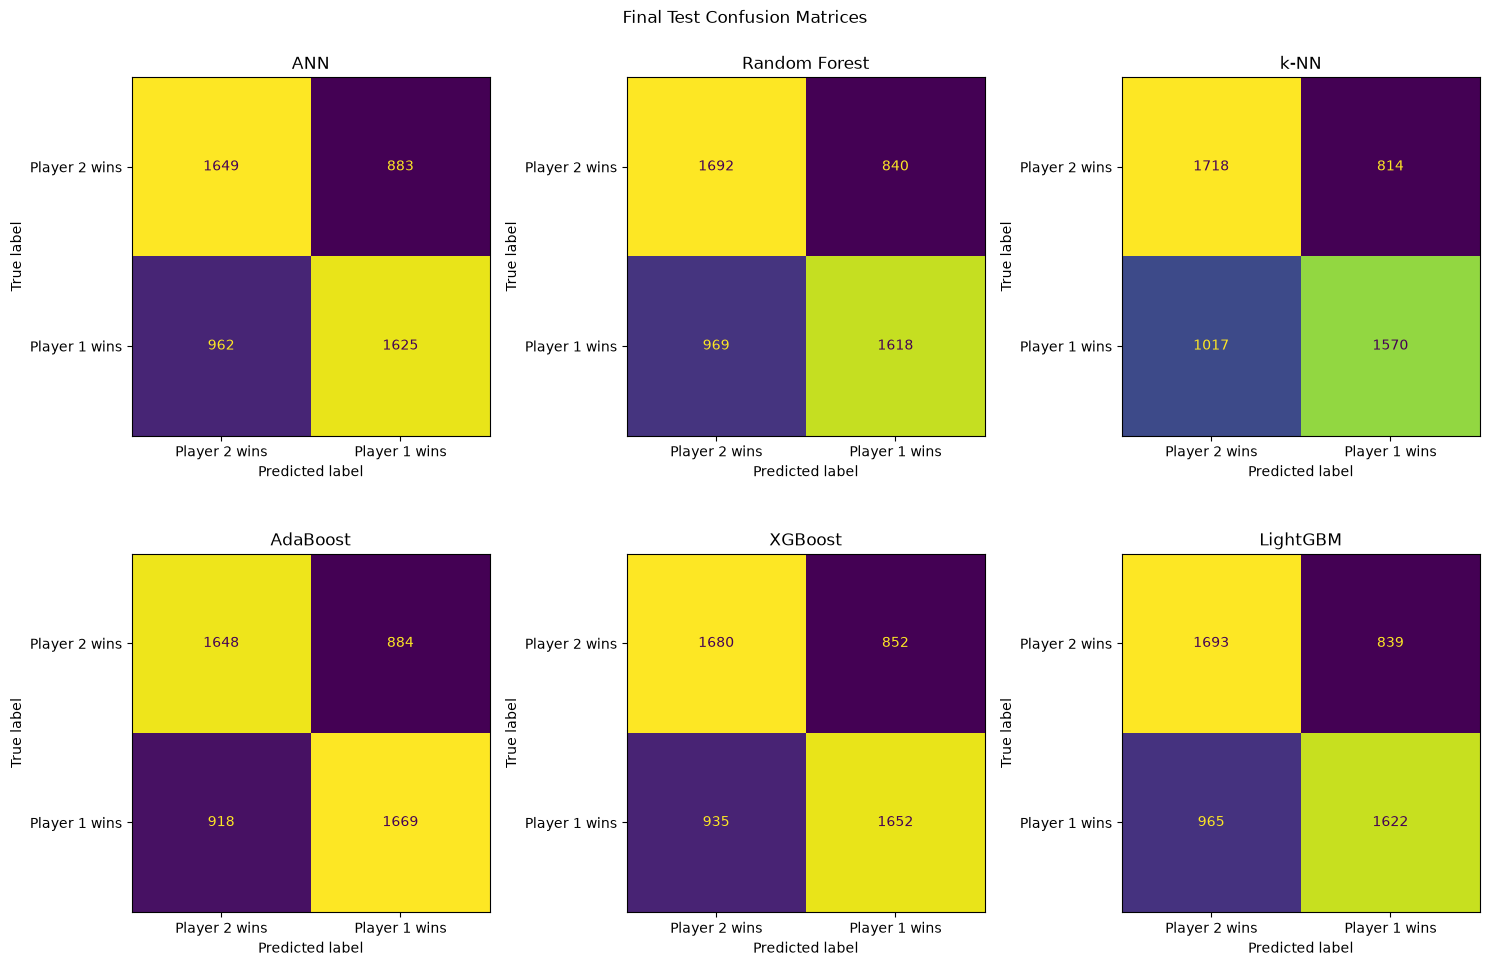

In [22]:
# show one confusion matrix for each final model
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 10)
)

# plt.subplots(2, 3) creates a 2×3 array of axes.
# .flatten() turns it into a simple sequence: ax1, ax2, etc.
# which makes the loop easier.

axes = axes.flatten()

for ax, (
    model_name,
    prefix
) in zip(
    axes,
    model_columns.items()
):

    ConfusionMatrixDisplay.from_predictions(
        final_test_predictions[
            "Player1Won"
        ],

        final_test_predictions[
            prefix + "Prediction"
        ],

        display_labels=[
            "Player 2 wins",
            "Player 1 wins"
        ],

        values_format="d",

        colorbar=False,

        ax=ax
    )

    ax.set_title( model_name)


plt.suptitle("Final Test Confusion Matrices")

plt.tight_layout()

plt.show()

In [23]:
# print precision, recall and F1 separately for both classes
for (
    model_name,
    prefix
) in model_columns.items():

    print("\n", "=" * 60)

    print(model_name)

    print( "=" * 60)


    print(
        classification_report(
            final_test_predictions[
                "Player1Won"
            ],

            final_test_predictions[
                prefix + "Prediction"
            ],

            target_names=[
                "Player 2 wins",
                "Player 1 wins"
            ],
            
            zero_division=0
        )
    )


ANN
               precision    recall  f1-score   support

Player 2 wins       0.63      0.65      0.64      2532
Player 1 wins       0.65      0.63      0.64      2587

     accuracy                           0.64      5119
    macro avg       0.64      0.64      0.64      5119
 weighted avg       0.64      0.64      0.64      5119


Random Forest
               precision    recall  f1-score   support

Player 2 wins       0.64      0.67      0.65      2532
Player 1 wins       0.66      0.63      0.64      2587

     accuracy                           0.65      5119
    macro avg       0.65      0.65      0.65      5119
 weighted avg       0.65      0.65      0.65      5119


k-NN
               precision    recall  f1-score   support

Player 2 wins       0.63      0.68      0.65      2532
Player 1 wins       0.66      0.61      0.63      2587

     accuracy                           0.64      5119
    macro avg       0.64      0.64      0.64      5119
 weighted avg       0.64      0

The classification reports show that the models perform quite similarly for Player 1 and Player 2 wins.

There is no major class imbalance problem, although some models have slightly lower recall for Player 1 victories.

## Performance over time

The final test period contains two separate seasons: 2024 and 2025.

We compare them separately to check whether model performance is reasonably stable over time or whether the result is mainly caused by one particularly good year.

In [24]:
# calculate the accuracy of each model separately for 2024 and 2025
year_results = []


for (
    model_name,
    prefix
) in model_columns.items():

    for (
        year,
        year_data
    ) in final_test_predictions.groupby(
        final_test_predictions[
            "Date"
        ].dt.year
    ):

        year_results.append(
            {
                "Model": model_name,
                "Year":year,
                "Matches": len( year_data),
                "Accuracy": year_data[ prefix + "Correct"].mean()
            }
        )


year_results = pd.DataFrame(year_results)

year_results

year_results.pivot(
    index="Model",
    columns="Year",
    values="Accuracy"
).round(4)

Year,2024,2025
Model,,
ANN,0.6416,0.6375
AdaBoost,0.6492,0.6467
LightGBM,0.6454,0.6499
Random Forest,0.6450,0.6483
XGBoost,0.6439,0.6584
k-NN,0.6332,0.6519


Performance remains fairly stable between the two years.

XGBoost improves from approximately **64.4% in 2024** to **65.8% in 2025**, while the other models also remain in a similar range.

This suggests that the final result is not caused by performance in only one year.

## Performance by court surface

Tennis matches can behave differently on hard, clay and grass courts.

Since surface-related features were included in the project, we check whether model accuracy changes substantially depending on the surface.

In [25]:
# calculate model accuracy separately for each court surface
surface_results = []


for (
    model_name,
    prefix
) in model_columns.items():

    for (
        surface,
        surface_data
    ) in final_test_predictions.groupby(
        "Surface"
    ):

        surface_results.append(
            {
                "Model":model_name,
                "Surface":surface,
                "Matches":len(surface_data),
                "Accuracy": surface_data[ prefix + "Correct"].mean()
            }
        )


surface_results = pd.DataFrame(
    surface_results
)

surface_results.pivot(
    index="Model",
    columns="Surface",
    values="Accuracy"
).round(4)

Surface,Clay,Grass,Hard
Model,,,
ANN,0.6339,0.6237,0.6458
AdaBoost,0.6383,0.6472,0.6532
LightGBM,0.6460,0.6505,0.6478
Random Forest,0.6326,0.6488,0.6536
XGBoost,0.6441,0.6538,0.6539
k-NN,0.6281,0.6405,0.6502


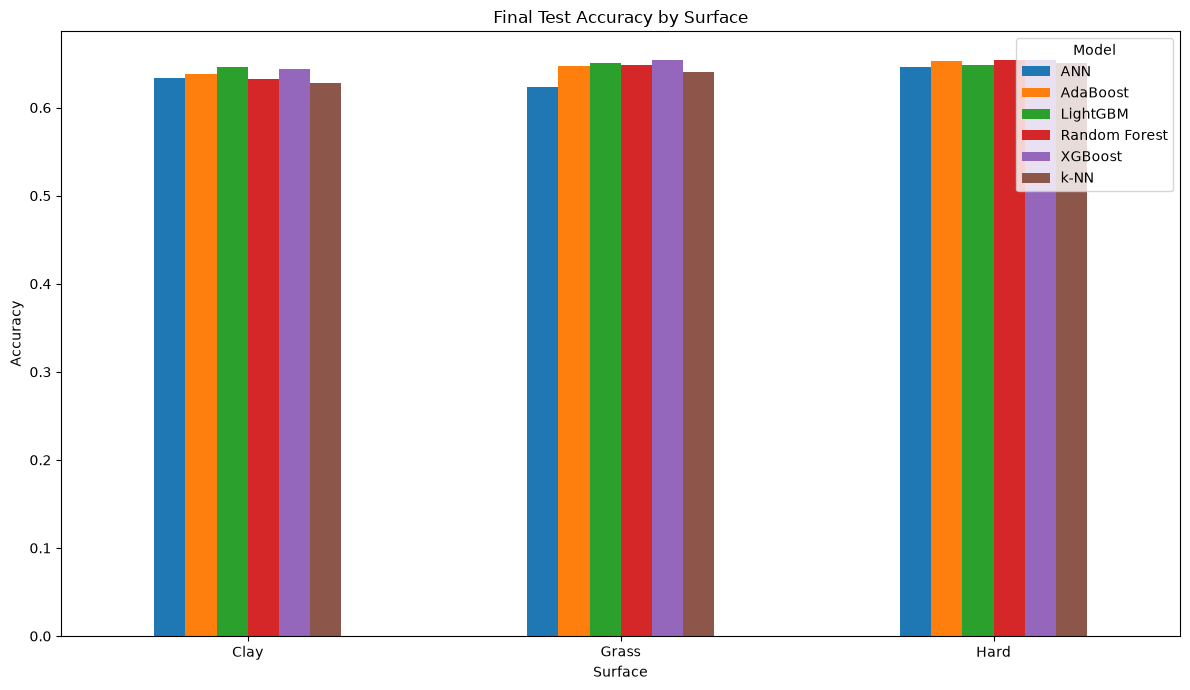

In [26]:
# create a grouped bar chart to compare surfaces across models
surface_plot = (
    surface_results
    .pivot(
        index="Surface",
        columns="Model",
        values="Accuracy"
    )
)

surface_plot.plot(
    kind="bar",
    figsize=(12, 7)
)


plt.ylabel("Accuracy")

plt.xlabel("Surface")

plt.title("Final Test Accuracy by Surface")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

The differences between surfaces are relatively small.

Most models perform slightly better on hard courts and slightly worse on clay, although the exact pattern depends on the model.

This suggests that no single surface is responsible for the overall model performance.

## Match difficulty based on ranking difference

A match between two similarly ranked players should intuitively be harder to predict than a match between players with very different rankings.

To test this, we use the absolute ranking difference between the two players and divide matches into five groups.

In [27]:
# only the size of the ranking gap matters here,
# not which player has the better ranking
final_test_predictions[
    "AbsoluteRankDifference"
] = (
    final_test_predictions["RankDifference"].abs()
)

# divide matches into groups based on how far apart the players are ranked
final_test_predictions[
    "RankGapGroup"
] = pd.cut(
    final_test_predictions["AbsoluteRankDifference"],

    bins=[
        -0.001, # a lower bounday below 0 ensures 0 is included
        10,
        25,
        50,
        100,
        np.inf
    ],

    labels=[
        "0–10",
        "11–25",
        "26–50",
        "51–100",
        "100+"
    ]
)

In [28]:
# calculate accuracy for every model inside each ranking-gap group
rank_gap_results = []


for (
    model_name,
    prefix
) in model_columns.items():

    for (
        rank_gap,
        group_data
    ) in final_test_predictions.groupby(
        "RankGapGroup",
        observed=False
    ):

        rank_gap_results.append(
            {
                "Model":model_name,
                "RankGap":rank_gap,
                "Matches": len(group_data),
                "Accuracy":group_data[prefix + "Correct"].mean()
            }
        )


rank_gap_results = pd.DataFrame(
    rank_gap_results
)

rank_gap_results.pivot(
    index="Model",
    columns="RankGap",
    values="Accuracy"
).round(4)

RankGap,0–10,100+,11–25,26–50,51–100
Model,,,,,
ANN,0.5732,0.7085,0.5915,0.6192,0.6900
AdaBoost,0.6043,0.6983,0.5905,0.6321,0.7007
LightGBM,0.5786,0.6994,0.5977,0.6398,0.6998
Random Forest,0.5827,0.7051,0.6008,0.6367,0.6900
XGBoost,0.6043,0.6960,0.6008,0.6428,0.6949
k-NN,0.6003,0.7028,0.5988,0.6222,0.6801


The relationship is quite clear: matches between similarly ranked players are more difficult to predict.

For example, when the ranking difference is at most 10 positions, model accuracy is generally around **57-60%**. When the players are more than 100 ranking positions apart, accuracy increases to approximately **70%**.

This confirms that relative player strength has a strong effect on how predictable a match is.

## Agreement between the models

Since all six models predict the same matches, we can check how often they agree on whether a match is easy or difficult.

For every match we count how many of the six models predicted the winner correctly.

In [29]:
# collect the six columns that indicate whether each model was correct
correct_columns = [
    prefix + "Correct"

    for prefix
    in model_columns.values()
]

# True counts as 1 and False as 0,
# so the sum gives the number of correct models for each match
final_test_predictions[
    "ModelsCorrect"
] = (
    final_test_predictions[
        correct_columns
    ].sum(axis=1)
)

final_test_predictions[
    "ModelsCorrect"
].value_counts().sort_index()

ModelsCorrect
0    1176
1     345
2     172
3     190
4     220
5     399
6    2617
Name: count, dtype: int64

In [30]:
# matches that every model predicted correctly
all_models_correct = (
    final_test_predictions.loc[
        final_test_predictions[
            "ModelsCorrect"
        ] == 6
    ]
)

# matches that every model predicted incorrectly
all_models_wrong = (
    final_test_predictions.loc[
        final_test_predictions[
            "ModelsCorrect"
        ] == 0
    ]
)


print(
    "All six correct:",
    len( all_models_correct)
)

print(
    "All six wrong:",
    len( all_models_wrong)
)

All six correct: 2617
All six wrong: 1176


There is a large amount of agreement between the models.

All six classifiers are correct on **2,617 matches**, but all six are wrong on **1,176 matches**.

This suggests that many errors are caused by matches that are intrinsically difficult given the available information, rather than only by weaknesses of one specific algorithm.

## Ranking upsets

A ranking upset occurs when the worse-ranked player wins the match.

Since the better-ranked-player baseline is already strong, these matches are particularly interesting: they represent situations where ranking gives the wrong signal.

In [31]:
# a match is considered an upset when the winner had the worse ATP ranking
# remember: a larger ranking number means a worse ranking

final_test_predictions[
    "RankingUpset"
] = np.where(
    final_test_predictions[
        "Player1Won"
    ] == 1,

    # if Player 1 won, check whether Player 1 was worse ranked
    final_test_predictions[
        "Player1Rank"
    ]
    >
    final_test_predictions[
        "Player2Rank"
    ],

    # otherwise Player 2 won, so check whether Player 2 was worse ranked
    final_test_predictions[
        "Player2Rank"
    ]
    >
    final_test_predictions[
        "Player1Rank"
    ]
)

print(
    "Ranking upsets:",
    final_test_predictions[
        "RankingUpset"
    ].sum()
)

print(
    "Upset percentage:",
    final_test_predictions[
        "RankingUpset"
    ].mean()
)

Ranking upsets: 1830
Upset percentage: 0.35749169759718696


In [32]:
# create absolute differences so that we compare how far apart
# the two players were without considering which player had the higher value

final_test_predictions[
    "AbsolutePointsDifference"
] = (final_test_predictions[
    "PointsDifference"
].abs())

final_test_predictions[
    "AbsoluteWinRateDifference"
] = (final_test_predictions[
    "WinRateDifference"
].abs())

final_test_predictions[
    "AbsoluteSurfaceWinRateDifference"
] = (final_test_predictions[
    "SurfaceWinRateDifference"
].abs())

#AbsoluteRankDifference already created above 


In [33]:
# create independent copies for the detailed comparison
all_models_correct = (
    final_test_predictions.loc[
        final_test_predictions[
            "ModelsCorrect"
        ] == 6
    ].copy()
)

all_models_wrong = (
    final_test_predictions.loc[
        final_test_predictions[
            "ModelsCorrect"
        ] == 0
    ].copy()
)

### What makes a match easy or difficult?

We compare matches where all six models were correct with matches where all six models were wrong.

We look at ranking, ranking points, overall win rate, surface win rate and whether the result was a ranking upset.

In [34]:
# compare the typical characteristics of easy and difficult matches
correct_wrong_comparison = pd.DataFrame(
    {
       "Characteristic": [
            "Number of matches",
            "Median absolute rank difference",
            "Median absolute points difference",
            "Median absolute win-rate difference",
            "Median absolute surface win-rate difference",
            "Ranking upset percentage"
        ], 
       
       "All models correct": [
           len(all_models_correct),
           all_models_correct["AbsoluteRankDifference"].median(),
           all_models_correct["AbsolutePointsDifference"].median(),
           all_models_correct["AbsoluteWinRateDifference"].median(),
           all_models_correct["AbsoluteSurfaceWinRateDifference"].median(),
           all_models_correct["RankingUpset"].mean()*100
       ],
       
       "All models wrong": [
            len(all_models_wrong),
            all_models_wrong["AbsoluteRankDifference"].median(),
            all_models_wrong["AbsolutePointsDifference"].median(),
            all_models_wrong["AbsoluteWinRateDifference"].median(),
            all_models_wrong["AbsoluteSurfaceWinRateDifference"].median(),
            all_models_wrong["RankingUpset"].mean()*100
        ],
    }
)

correct_wrong_comparison

,Characteristic,All models correct,All models wrong
0,Number of matches,2617.000000,1176.000000
1,Median absolute rank difference,51.000000,43.000000
2,Median absolute points difference,1195.000000,696.500000
3,Median absolute win-rate difference,0.128176,0.096095
4,Median absolute surface win-rate difference,0.134615,0.104145
5,Ranking upset percentage,4.508980,93.877551


The difference between the two groups is very clear.

Matches where all models are correct tend to have larger differences between the players in ranking, points and previous win rates.

The strongest result concerns ranking upsets:

- only about **4.5%** of matches where all models were correct are ranking upsets
- about **93.9%** of matches where all models were wrong are ranking upsets

This shows that unexpected wins by the worse-ranked player are one of the main sources of prediction errors.

In [35]:
# save the easy-vs-difficult match comparison
correct_wrong_comparison.to_csv(
    FINAL_RESULTS_DIR
    / "correct_vs_wrong_feature_distribution.csv",
    index=False
)

print("Correct-vs-wrong feature distribution saved.")

Correct-vs-wrong feature distribution saved.


### Model performance on ranking upsets

We now evaluate the models separately on:

- normal matches, where the better-ranked player wins
- ranking upsets, where the worse-ranked player wins

This allows us to see whether the machine-learning models are actually able to identify unexpected outcomes.

In [36]:
# calculate each model's accuracy separately for normal matches and upsets
upset_results = []


for (
    model_name,
    prefix
) in model_columns.items():

    for upset_status in [
        False,
        True
    ]:

        subset = (
            final_test_predictions.loc[
                final_test_predictions[
                    "RankingUpset"
                ] == upset_status
            ]
        )


        upset_results.append(
            {
                "Model": model_name,
                "RankingUpset": upset_status,
                "Accuracy": subset[prefix + "Correct"].mean()
            }
        )


upset_results = pd.DataFrame(upset_results)

upset_results.pivot(
    index="Model",
    columns="RankingUpset",
    values="Accuracy"
).round(4)

RankingUpset,False,True
Model,,
ANN,0.8553,0.2519
AdaBoost,0.9462,0.1120
LightGBM,0.9109,0.1743
Random Forest,0.9067,0.1792
XGBoost,0.9404,0.1306
k-NN,0.8416,0.2842


All models perform very well when the better-ranked player wins, but performance drops dramatically on ranking upsets.

For example, XGBoost reaches approximately **94.0% accuracy on non-upsets**, but only about **13.1% on ranking upsets**.

Interestingly, k-NN and ANN identify a larger proportion of upsets than the tree-based models, although their overall accuracy is lower.

This confirms that most models rely strongly, directly or indirectly, on indicators of player strength such as ranking and historical performance.

## Prediction confidence

The models also produce probabilities, which allow us to measure how confident they are in their predictions.

We check the accuracy obtained when considering only matches for which model confidence is at least 60%, 70% or 80%.

If the predicted probabilities are useful, accuracy should generally increase when we keep only more confident predictions.

In [37]:
# check model accuracy at different minimum confidence levels
confidence_results = []


for threshold in [
    0.60,
    0.70,
    0.80
]:

    for (
        model_name,
        prefix
    ) in model_columns.items():

        # keep only predictions whose confidence is above the threshold
        confident_matches = (
            final_test_predictions.loc[
                final_test_predictions[
                    prefix + "Confidence"
                ] >= threshold
            ]
        )


        confidence_results.append(
            {
                "Model": model_name,
                "ConfidenceThreshold":threshold,
                "Matches": len(confident_matches),
                "Accuracy":confident_matches[prefix + "Correct"].mean()
            }
        )


confidence_results = pd.DataFrame(
    confidence_results
)

confidence_results

,Model,ConfidenceThreshold,Matches,Accuracy
0,ANN,0.6,3224,0.704715
1,Random Forest,0.6,2954,0.729181
2,k-NN,0.6,2601,0.727797
3,AdaBoost,0.6,2694,0.731626
4,XGBoost,0.6,3246,0.710721
5,LightGBM,0.6,3211,0.713796
6,ANN,0.7,1706,0.771395
7,Random Forest,0.7,1427,0.786966
8,k-NN,0.7,932,0.807940
9,AdaBoost,0.7,838,0.834129


As expected, accuracy generally increases when only higher-confidence predictions are considered.

However, the number of available matches decreases at the same time.

For example, XGBoost predicts 568 matches with at least 80% confidence and is correct on approximately **85.4%** of them.

This shows the trade-off between **coverage** and **accuracy**: requiring higher confidence gives fewer predictions, but the remaining predictions tend to be more reliable.

Another example is for AdaBoost that gets 94.96% accuracy at confidence ≥ 0.8, but only on 119 matches. That does not mean that AdaBoost is the best model, because 119 matches is a very tiny subset.

### High-confidence XGBoost mistakes

Even a confident model can still be wrong.

Since XGBoost is the final best-performing model, we inspect the matches where it assigned at least 80% confidence to its prediction but still predicted the wrong winner.

These cases are useful examples of outcomes that were particularly unexpected given the information available to the model.

In [38]:
# keep XGBoost mistakes where prediction confidence was at least 80%
xgboost_high_confidence_errors = (
    final_test_predictions.loc[
        (
            final_test_predictions[
                "XGBoostConfidence"
            ]>= 0.80
        )
        &
        (
            final_test_predictions[
                "XGBoostCorrect"
            ] == False
        )
    ]
)

print(
    "High-confidence XGBoost errors:",
    len( xgboost_high_confidence_errors)
)

# show a few examples to inspect manually
display(
    xgboost_high_confidence_errors[
        [
            "Date",
            "Tournament",
            "Surface",
            "Player1",
            "Player2",
            "Player1Rank",
            "Player2Rank",
            "Player1Won",
            "XGBoostPrediction",
            "XGBoostProbability",
            "XGBoostConfidence"
        ]
    ].head(20)
)

High-confidence XGBoost errors: 83


,Date,Tournament,Surface,Player1,Player2,Player1Rank,Player2Rank,Player1Won,XGBoostPrediction,XGBoostProbability,XGBoostConfidence
185,2024-01-18,Australian Open,Hard,Rune H.,Cazaux A.,8.0,122.0,0,1,0.852464,0.852464
206,2024-01-20,Australian Open,Hard,Dimitrov G.,Borges N.,13.0,69.0,0,1,0.811407,0.811407
226,2024-01-26,Australian Open,Hard,Sinner J.,Djokovic N.,4.0,1.0,1,0,0.199855,0.800145
405,2024-02-17,Argentina Open,Clay,Jarry N.,Alcaraz C.,21.0,2.0,1,0,0.130869,0.869131
460,2024-02-21,Rio Open,Clay,Fonseca J.,Fils A.,655.0,36.0,1,0,0.152168,0.847832
531,2024-02-28,Abierto Mexicano,Hard,Altmaier D.,Zverev A.,57.0,6.0,1,0,0.154966,0.845033
569,2024-03-01,Dubai Tennis Championships,Hard,Humbert U.,Medvedev D.,18.0,4.0,1,0,0.160864,0.839136
659,2024-03-12,BNP Paribas Open,Hard,Djokovic N.,Nardi L.,1.0,123.0,0,1,0.926898,0.926898
705,2024-03-22,Miami Open,Hard,Rublev A.,Machac T.,6.0,60.0,0,1,0.806438,0.806438
721,2024-03-23,Miami Open,Hard,Fritz T.,Seyboth Wild T.,13.0,76.0,0,1,0.805567,0.805567


In [39]:
# explicitly select the model with the highest final test accuracy
best_model = (final_model_results.iloc[0])

print("=" * 70)
print("FINAL EVALUATION SUMMARY")
print( "=" * 70)


print("\nBest model:")
print(best_model["Model"])


print(
    "\nAccuracy:",
    round(best_model["Accuracy"], 4)
)


print(
    "ROC-AUC:",
    round(best_model["ROC-AUC"], 4)
)


print(
    "Log loss:",
    round(best_model["LogLoss"], 4)
)


print(
    "\nRanking baseline accuracy:",
    round(baseline_accuracy, 4)
)

FINAL EVALUATION SUMMARY

Best model:
XGBoost

Accuracy: 0.6509
ROC-AUC: 0.7119
Log loss: 0.6179

Ranking baseline accuracy: 0.6425


## Final conclusions

XGBoost achieved the best overall performance among the six machine-learning models on the untouched 2024-2025 test set, with approximately **65.1% accuracy**, **0.712 ROC-AUC** and **0.618 LogLoss**.

AdaBoost, LightGBM and Random Forest produced very similar results, showing that the tree-based ensemble models were the strongest approaches tested in this project.

The simple better-ranked-player baseline already achieved approximately **64.3% accuracy**, so the improvement obtained by XGBoost is relatively small. However, it shows that the additional historical features contain some useful information beyond ranking alone.

The bookmaker benchmark performed better than all of our models, reaching approximately **68.5% accuracy** on the matches where odds were available. This suggests that the betting market contains additional information that is not represented in our dataset.

The error analysis also showed that matches between similarly ranked players are more difficult to predict and that ranking upsets are the main source of errors. Almost 94% of the matches where all six models failed were ranking upsets.

Overall, the project shows that tennis match outcomes are predictable to some extent using historical pre-match information, but a large amount of uncertainty remains, especially when unexpected results occur.